<a href="https://colab.research.google.com/github/ariapatrikaki/Machine-Learning/blob/main/Alzheimer%E2%80%99s%20Disease%20Diagnosis/Predict_Alzheimer's_Disease.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


## 💡 Project Overview

This project aims to predict Alzheimer's Disease diagnosis using machine learning classifiers. It uses a medical dataset related to Alzheimer's diagnosis.
We apply two machine learning models: **K-Nearest Neighbors (KNN)** and **Decision Tree**, and evaluate their performance under different train-test splits.

We assess performance using accuracy, precision, recall, and F1-score.

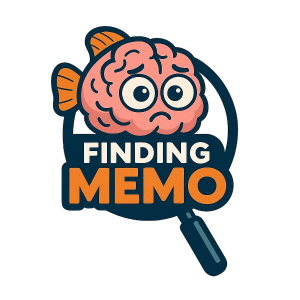


# Importing Libraries
In this cell, we import the necessary Python libraries for data manipulation, visualization, and machine learning. `pandas` and `numpy` are used for handling data, `matplotlib` and `seaborn` for plotting, and `sklearn` for building ML models.

In [ ]:
#Importing all the necessary libraries.

import pandas as pd
import numpy as np
import kagglehub
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold

from sklearn import tree
from matplotlib import pyplot as plt
import seaborn as sns

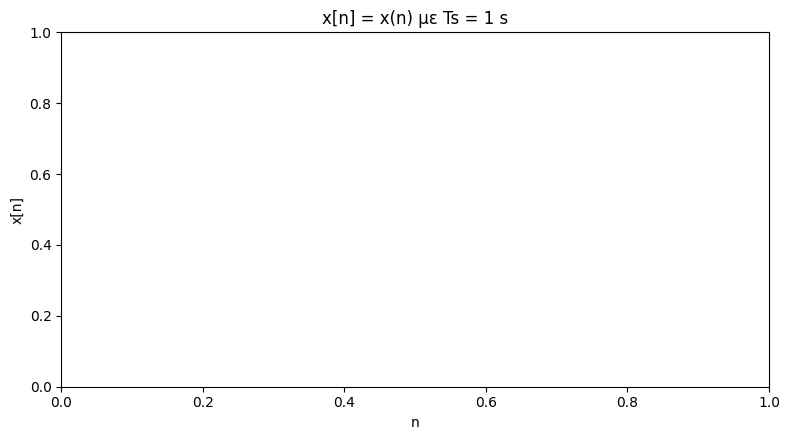

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# x(t) = sinc^2(t/2)  ->  samples x[n] = x(n) for Ts = 1 s (Nyquist)
def x_t(t):
    return np.sinc(t/2.0)**2

n = np.arange(-12, 13)
xn = x_t(n)

plt.figure(figsize=(8,4.5))
plt.title("x[n] = x(n) με Ts = 1 s")
plt.xlabel("n")
plt.ylabel("x[n]")
plt.tight_layout()
plt.show()

# 📂 Load and explore data

---

# 📥 Loading the Dataset
This cell reads the dataset into a pandas DataFrame so we can begin analysis and processing.

In [ ]:
# Download the Alzheimer's Disease Datasett from Kaggle using kagglehub

# Download latest version
path = kagglehub.dataset_download("rabieelkharoua/alzheimers-disease-dataset")

csv_path = f"{path}/alzheimers_disease_data.csv"

df = pd.read_csv(csv_path)

print("Column headers:", df.columns.tolist())

Column headers: ['PatientID', 'Age', 'Gender', 'Ethnicity', 'EducationLevel', 'BMI', 'Smoking', 'AlcoholConsumption', 'PhysicalActivity', 'DietQuality', 'SleepQuality', 'FamilyHistoryAlzheimers', 'CardiovascularDisease', 'Diabetes', 'Depression', 'HeadInjury', 'Hypertension', 'SystolicBP', 'DiastolicBP', 'CholesterolTotal', 'CholesterolLDL', 'CholesterolHDL', 'CholesterolTriglycerides', 'MMSE', 'FunctionalAssessment', 'MemoryComplaints', 'BehavioralProblems', 'ADL', 'Confusion', 'Disorientation', 'PersonalityChanges', 'DifficultyCompletingTasks', 'Forgetfulness', 'Diagnosis', 'DoctorInCharge']


# Understand the dataframe

In [ ]:
#Displaying basic information about the dataset: number of rows and columns,
# feature names, and the data types of each column

print("Informations of Database:")
print("• Number of rows : ", df.shape[0])    #rows=dataframe.shape[0]
print("• Number of columns : ", df.shape[1])  #columns=dataframe.shape[1]
print("• Names and Types of features : \n", df.dtypes)

Informations of Database:
• Number of rows :  2149
• Number of columns :  35
• Names and Types of features : 
 PatientID                      int64
Age                            int64
Gender                         int64
Ethnicity                      int64
EducationLevel                 int64
BMI                          float64
Smoking                        int64
AlcoholConsumption           float64
PhysicalActivity             float64
DietQuality                  float64
SleepQuality                 float64
FamilyHistoryAlzheimers        int64
CardiovascularDisease          int64
Diabetes                       int64
Depression                     int64
HeadInjury                     int64
Hypertension                   int64
SystolicBP                     int64
DiastolicBP                    int64
CholesterolTotal             float64
CholesterolLDL               float64
CholesterolHDL               float64
CholesterolTriglycerides     float64
MMSE                         float64
F

# 👀 Preview the Dataset
Here we preview the first few rows of the dataset to understand its structure and contents.

In [ ]:
df.head()

,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis,DoctorInCharge
0,4751,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,...,0,0,1.725883,0,0,0,1,0,0,XXXConfid
1,4752,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,...,0,0,2.592424,0,0,0,0,1,0,XXXConfid
2,4753,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,...,0,0,7.119548,0,1,0,1,0,0,XXXConfid
3,4754,74,1,0,1,33.800817,1,12.209266,8.428001,7.435604,...,0,1,6.481226,0,0,0,0,0,0,XXXConfid
4,4755,89,0,0,0,20.716974,0,18.454356,6.310461,0.795498,...,0,0,0.014691,0,0,1,1,0,0,XXXConfid


# 🧾 Dataset Info
Displays data types, non-null counts, and general structure to help assess data quality.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2149 entries, 0 to 2148
Data columns (total 35 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   PatientID                  2149 non-null   int64  
 1   Age                        2149 non-null   int64  
 2   Gender                     2149 non-null   int64  
 3   Ethnicity                  2149 non-null   int64  
 4   EducationLevel             2149 non-null   int64  
 5   BMI                        2149 non-null   float64
 6   Smoking                    2149 non-null   int64  
 7   AlcoholConsumption         2149 non-null   float64
 8   PhysicalActivity           2149 non-null   float64
 9   DietQuality                2149 non-null   float64
 10  SleepQuality               2149 non-null   float64
 11  FamilyHistoryAlzheimers    2149 non-null   int64  
 12  CardiovascularDisease      2149 non-null   int64  
 13  Diabetes                   2149 non-null   int64

# Summary Statistics
This gives an overview of the dataset’s statistical properties such as mean, std, min, and max values.

In [ ]:
df.describe()

,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,FunctionalAssessment,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis
count,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,...,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000
mean,5825.000000,74.908795,0.506282,0.697534,1.286645,27.655697,0.288506,10.039442,4.920202,4.993138,...,5.080055,0.208004,0.156817,4.982958,0.205212,0.158213,0.150768,0.158678,0.301536,0.353653
std,620.507185,8.990221,0.500077,0.996128,0.904527,7.217438,0.453173,5.757910,2.857191,2.909055,...,2.892743,0.405974,0.363713,2.949775,0.403950,0.365026,0.357906,0.365461,0.459032,0.478214
min,4751.000000,60.000000,0.000000,0.000000,0.000000,15.008851,0.000000,0.002003,0.003616,0.009385,...,0.000460,0.000000,0.000000,0.001288,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5288.000000,67.000000,0.000000,0.000000,1.000000,21.611408,0.000000,5.139810,2.570626,2.458455,...,2.566281,0.000000,0.000000,2.342836,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,5825.000000,75.000000,1.000000,0.000000,1.000000,27.823924,0.000000,9.934412,4.766424,5.076087,...,5.094439,0.000000,0.000000,5.038973,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,6362.000000,83.000000,1.000000,1.000000,2.000000,33.869778,1.000000,15.157931,7.427899,7.558625,...,7.546981,0.000000,0.000000,7.581490,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000
max,6899.000000,90.000000,1.000000,3.000000,3.000000,39.992767,1.000000,19.989293,9.987429,9.998346,...,9.996467,1.000000,1.000000,9.999747,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


# 🔍 Preprocess the data

---

# ❓ Missing Values Check
We check for missing or null values to assess if we need data imputation or cleaning.

In [ ]:
df.drop("PatientID", axis=1, inplace=True)
df.drop("DoctorInCharge", axis=1, inplace=True)

# Display missing values
print("Missing values before handling:")
print(df.isnull().sum().sum())
print("\n")
print(df.isnull().sum())

Missing values before handling:
0


Age                          0
Gender                       0
Ethnicity                    0
EducationLevel               0
BMI                          0
Smoking                      0
AlcoholConsumption           0
PhysicalActivity             0
DietQuality                  0
SleepQuality                 0
FamilyHistoryAlzheimers      0
CardiovascularDisease        0
Diabetes                     0
Depression                   0
HeadInjury                   0
Hypertension                 0
SystolicBP                   0
DiastolicBP                  0
CholesterolTotal             0
CholesterolLDL               0
CholesterolHDL               0
CholesterolTriglycerides     0
MMSE                         0
FunctionalAssessment         0
MemoryComplaints             0
BehavioralProblems           0
ADL                          0
Confusion                    0
Disorientation               0
PersonalityChanges           0
DifficultyCompletingTasks    0
For

In [ ]:
df.dtypes

,0
Age,int64
Gender,int64
Ethnicity,int64
EducationLevel,int64
BMI,float64
Smoking,int64
AlcoholConsumption,float64
PhysicalActivity,float64
DietQuality,float64
SleepQuality,float64


# 📊 Plot the data

---

# Data Visualization
We visualize data distributions or relationships using Seaborn or Matplotlib. Plots help us understand patterns and correlations.

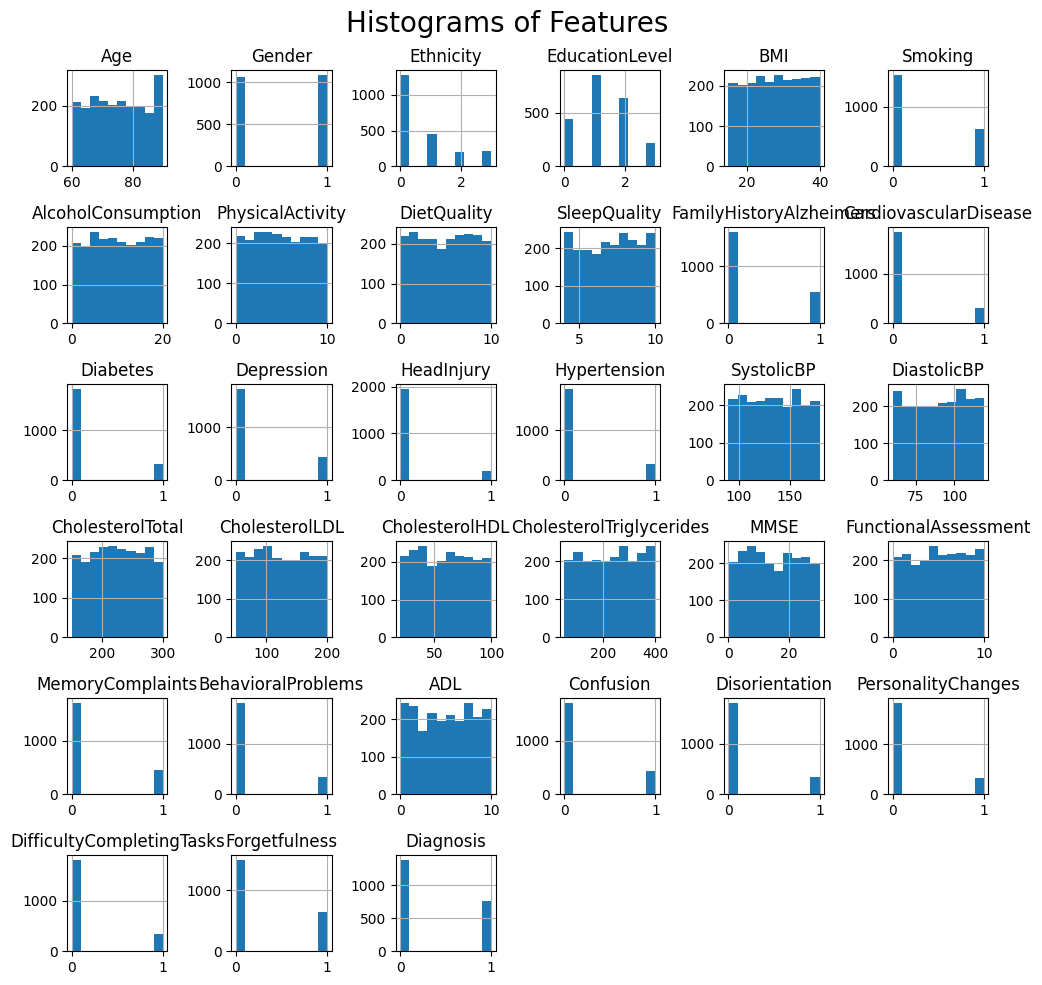

In [ ]:
# Plotting histograms to visualize how the values are distributed across each numeric feature
# in the dataset before performing further analysis

df.hist(figsize=(10,10))
plt.suptitle('Histograms of Features', fontsize=20)
plt.tight_layout()
plt.show()

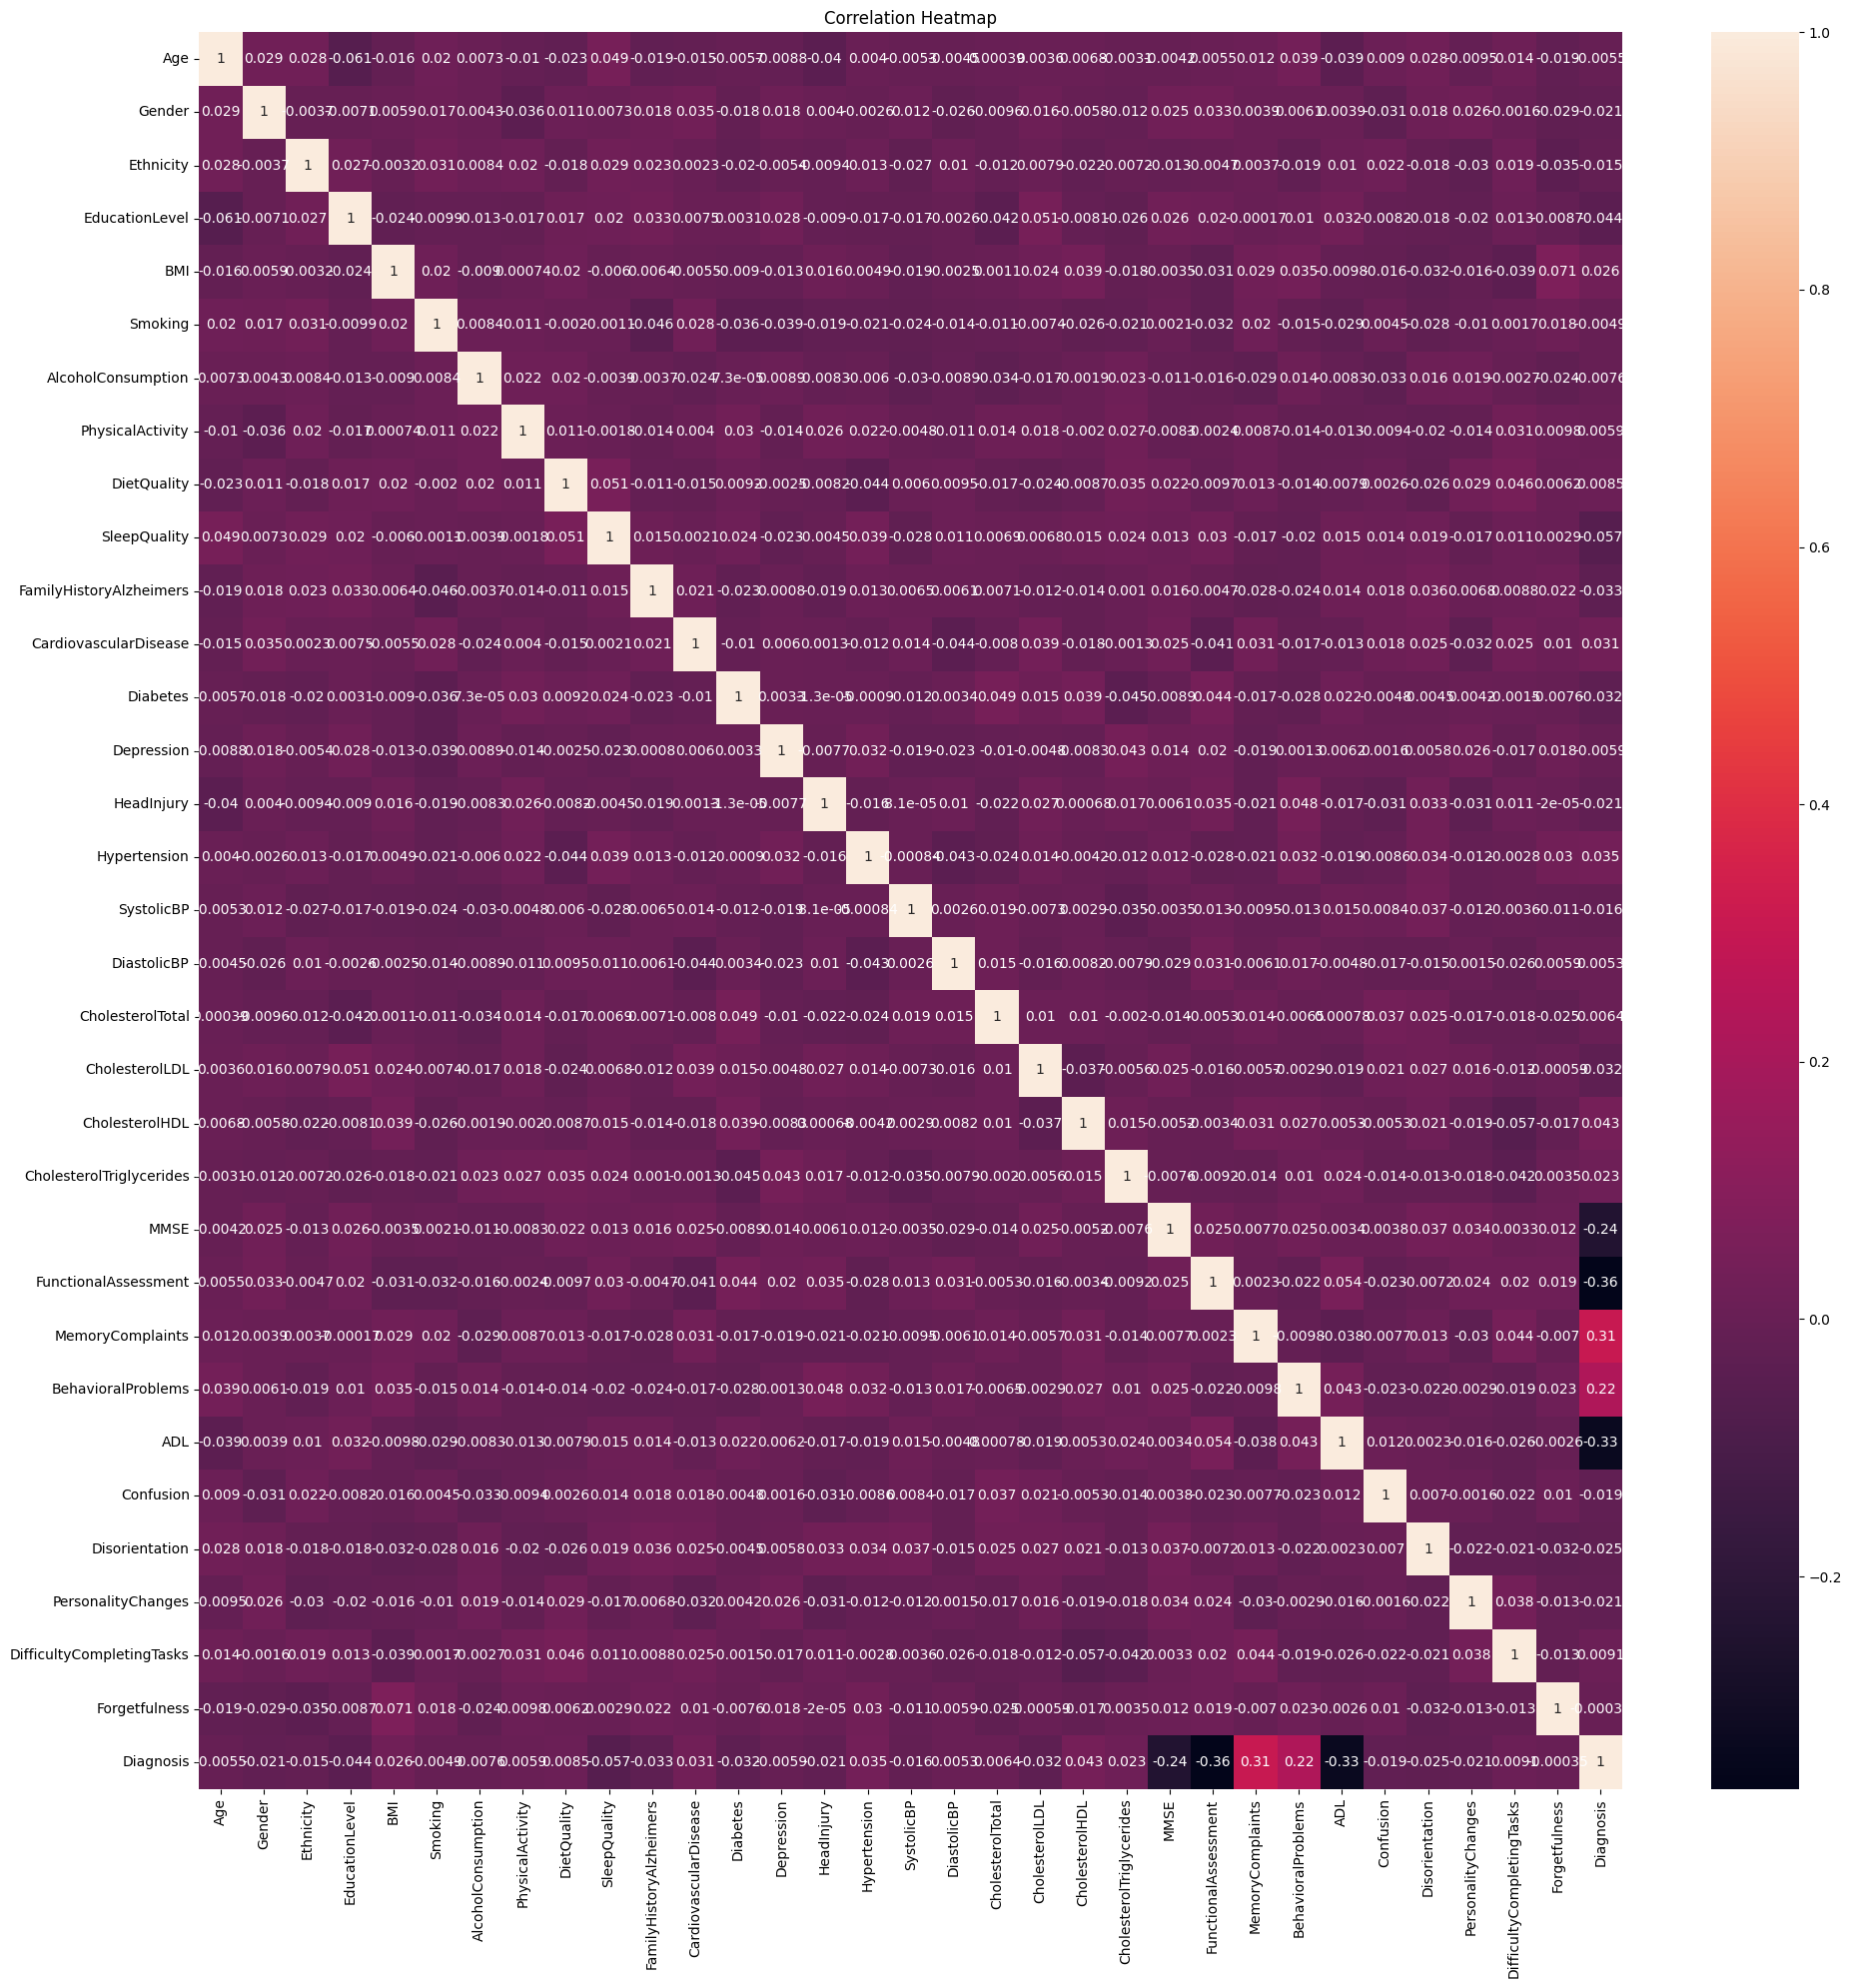

In [ ]:
# Plotting a correlation heatmap to visualize the relationships
#between numeric features in the dataset

fig = plt.figure(figsize=(20,20))
plt.title("Correlation Heatmap")
_=sns.heatmap(df.corr(),  annot=True)
plt.tight_layout()
plt.show()

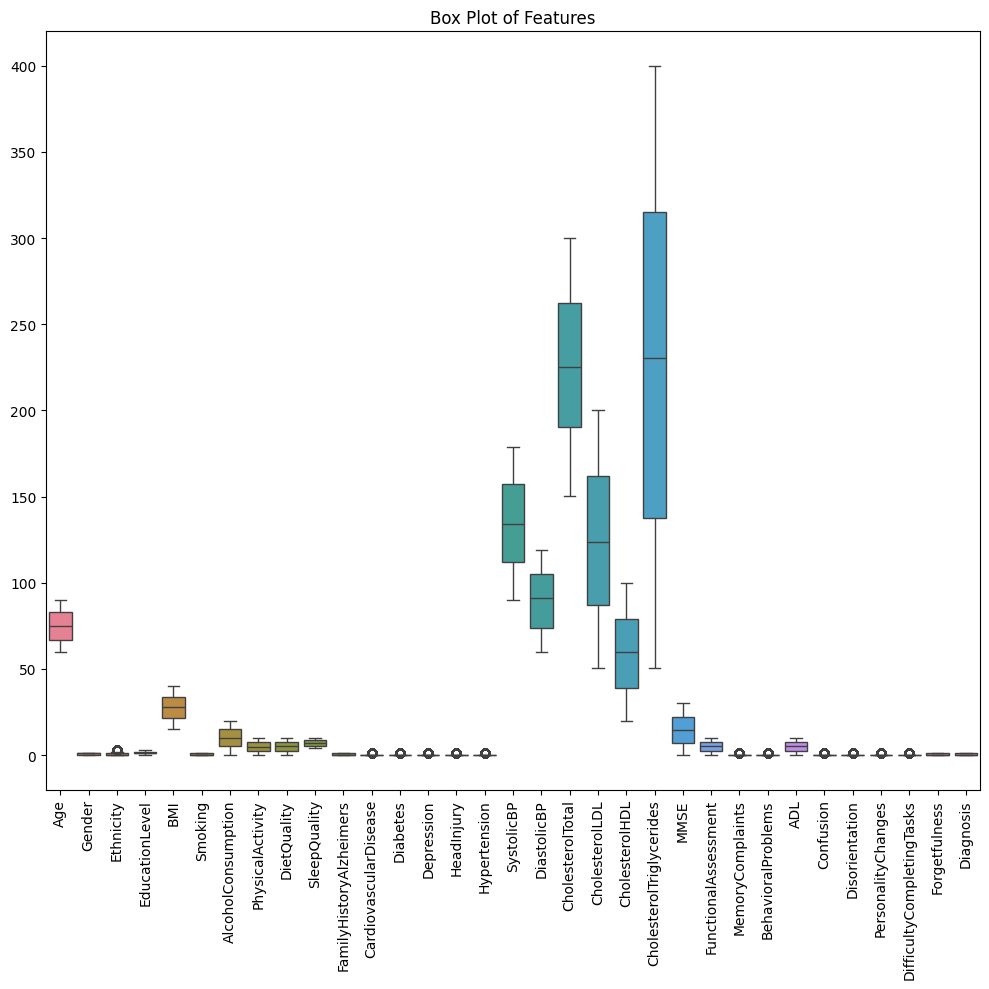

In [ ]:
# Plotting boxplot to visualize the distribution, spread,
#skewness, and outliers in dataframe.

fig=plt.figure(figsize=(10,10))
_=sns.boxplot(df)
plt.xticks(rotation=90)
plt.title('Box Plot of Features')
plt.tight_layout()
plt.show()

# 🛠️ Train and Evaluate a Decision Tree Classifier

---

# 📚 Splitting the Dataset
We divide the data into training and testing sets to train the model on one part and evaluate it on the other.

In [ ]:
#Train the model

# Define features (X) and stroke (y)
X = df.drop(['Diagnosis'], axis=1)
y = df['Diagnosis']

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 🌳 Training the Decision Tree Model


In [ ]:
#Initialize and train a Decision Tree model on the dataset

dt = DecisionTreeClassifier() #initialize
dt.fit(X_train, y_train) #train

# Predictions and evaluation
y_pred_dt = dt.predict(X_test)
print("Decision Tree Classification Report:\n")
print(classification_report(y_test, y_pred_dt))

Decision Tree Classification Report:

              precision    recall  f1-score   support

           0       0.92      0.93      0.92       277
           1       0.87      0.85      0.86       153

    accuracy                           0.90       430
   macro avg       0.90      0.89      0.89       430
weighted avg       0.90      0.90      0.90       430



# 🚀 Evaluate Model

# 🔮 Making Predictions
The trained model is used to make predictions on the test dataset.

In [ ]:
#Predict on test data

predictions = dt.predict(X_test)
predictions

array([0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1,
       1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0,
       0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0,
       1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1,
       0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1,
       1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1,
       0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0,
       1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1,
       0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0,
       1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0,

In [ ]:
dt.predict_proba(X_test) #probabilities for each class

array([[1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [0., 1.],
       [1., 0.],
       [1., 0.],
       [0., 1.],
       [0., 1.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [1., 0.],
       [0., 1.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [1., 0.],
       [1., 0.],
       [0., 1.

# Using accuracy, precision, recall, f1 score for evaluating the model

In [ ]:
print("Accuracy:", accuracy_score(y_test, predictions))
print("Precision:",precision_score(y_test, predictions))
print("Recall:",recall_score(y_test, predictions))
print("F1 Score:",f1_score(y_test, predictions))

Accuracy: 0.9023255813953488
Precision: 0.87248322147651
Recall: 0.8496732026143791
F1 Score: 0.8609271523178808


In [ ]:
#evaluate the classifier’s performance

report = classification_report(y_test, predictions, target_names=['No Alzheimer', 'Alzheimer'])
print(report)

              precision    recall  f1-score   support

No Alzheimer       0.92      0.93      0.92       277
   Alzheimer       0.87      0.85      0.86       153

    accuracy                           0.90       430
   macro avg       0.90      0.89      0.89       430
weighted avg       0.90      0.90      0.90       430



# Select only the Most Important Features for Improved Model Performance

In [ ]:
feature_names=X.columns
feature_importance = pd.DataFrame(dt.feature_importances_, index = feature_names).sort_values(0, ascending=False)
feature_importance

,0
MMSE,0.239347
ADL,0.212106
FunctionalAssessment,0.185562
MemoryComplaints,0.118452
BehavioralProblems,0.094711
CholesterolTriglycerides,0.017500
SleepQuality,0.016188
CholesterolTotal,0.015559
PhysicalActivity,0.015112
CholesterolHDL,0.014260


In [ ]:
features = list(feature_importance[feature_importance[0]>0.01].index)
print('The most important features are:\n', features)

The most important features are:
 ['MMSE', 'ADL', 'FunctionalAssessment', 'MemoryComplaints', 'BehavioralProblems', 'CholesterolTriglycerides', 'SleepQuality', 'CholesterolTotal', 'PhysicalActivity', 'CholesterolHDL', 'Age', 'DietQuality', 'AlcoholConsumption', 'CholesterolLDL', 'BMI']


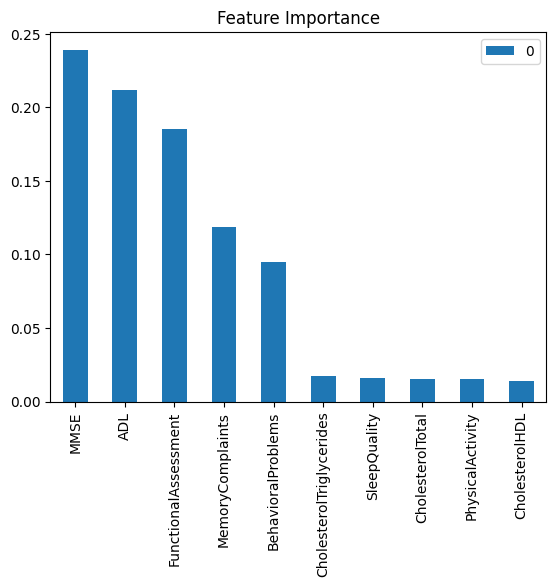

In [ ]:
feature_importance.head(10).plot(kind='bar')
plt.title("Feature Importance")
plt.show()

In [ ]:
low_importance = list(feature_importance[feature_importance[0]<0.01].index)

# Drop low importance features from the first dataframe X
# Removal (Drop Missing Data)
df = df.drop(columns=low_importance)
df.head()

,Age,BMI,AlcoholConsumption,PhysicalActivity,DietQuality,SleepQuality,CholesterolTotal,CholesterolLDL,CholesterolHDL,CholesterolTriglycerides,MMSE,FunctionalAssessment,MemoryComplaints,BehavioralProblems,ADL,Diagnosis
0,73,22.927749,13.297218,6.327112,1.347214,9.025679,242.366840,56.150897,33.682563,162.189143,21.463532,6.518877,0,0,1.725883,0
1,89,26.827681,4.542524,7.619885,0.518767,7.151293,231.162595,193.407996,79.028477,294.630909,20.613267,7.118696,0,0,2.592424,0
2,73,17.795882,19.555085,7.844988,1.826335,9.673574,284.181858,153.322762,69.772292,83.638324,7.356249,5.895077,0,0,7.119548,0
3,74,33.800817,12.209266,8.428001,7.435604,8.392554,159.582240,65.366637,68.457491,277.577358,13.991127,8.965106,0,1,6.481226,0
4,89,20.716974,18.454356,6.310461,0.795498,5.597238,237.602184,92.869700,56.874305,291.198780,13.517609,6.045039,0,0,0.014691,0


In [ ]:
df.head()

,Age,BMI,AlcoholConsumption,PhysicalActivity,DietQuality,SleepQuality,CholesterolTotal,CholesterolLDL,CholesterolHDL,CholesterolTriglycerides,MMSE,FunctionalAssessment,MemoryComplaints,BehavioralProblems,ADL,Diagnosis
0,73,22.927749,13.297218,6.327112,1.347214,9.025679,242.366840,56.150897,33.682563,162.189143,21.463532,6.518877,0,0,1.725883,0
1,89,26.827681,4.542524,7.619885,0.518767,7.151293,231.162595,193.407996,79.028477,294.630909,20.613267,7.118696,0,0,2.592424,0
2,73,17.795882,19.555085,7.844988,1.826335,9.673574,284.181858,153.322762,69.772292,83.638324,7.356249,5.895077,0,0,7.119548,0
3,74,33.800817,12.209266,8.428001,7.435604,8.392554,159.582240,65.366637,68.457491,277.577358,13.991127,8.965106,0,1,6.481226,0
4,89,20.716974,18.454356,6.310461,0.795498,5.597238,237.602184,92.869700,56.874305,291.198780,13.517609,6.045039,0,0,0.014691,0


# Remaking the DecisionTree after droping unimportant columns

In [ ]:
# Define features (X) and stroke (y)
X = df.drop(['Diagnosis'], axis=1)
y = df['Diagnosis']

# Split the data into training and testing sets (72% train, 28% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Re-initialize and train a Decision Tree model on the dataset

dt = DecisionTreeClassifier() #initialize
dt.fit(X_train, y_train) #train

DecisionTreeClassifier()

# 🧠  Fine-tune the Decision Tree Model

In [ ]:
# Define parameter grid
param_grid = {
    'max_depth': [3, 5, 10, 15, 17],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

# Initialize GridSearchCV
grid_search = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=5, scoring='f1')
grid_search.fit(X_train, y_train)

best_dt_model = grid_search.best_estimator_
predictions_best_dt = best_dt_model.predict(X_test)

# Compare the parametres of original and fine- tuned decision tree model

In [ ]:
# check parametres

print("Parameters of Decision Tree model:")
print(dt.get_params())
print("\n")

print("Parameters of fine-tuned Decision Tree model:")
print(best_dt_model.get_params())

Parameters of Decision Tree model:
{'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': None, 'splitter': 'best'}


Parameters of fine-tuned Decision Tree model:
{'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'entropy', 'max_depth': 5, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 10, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': 42, 'splitter': 'best'}


# Compare the accuracy of each model:

In [ ]:
print("Original Decision Tree Classification Report:")
print("Accuracy:", accuracy_score(y_test, predictions))
print("Precision:",precision_score(y_test, predictions))
print("Recall:",recall_score(y_test, predictions))
print("F1 Score:",f1_score(y_test, predictions))

print("\n")
print("Fine-tuned Decision Tree Classification Report:")
print("Accuracy:", accuracy_score(y_test, predictions_best_dt))
print("Precision:",precision_score(y_test, predictions_best_dt))
print("Recall:",recall_score(y_test,predictions_best_dt))
print("F1 Score:",f1_score(y_test, predictions_best_dt))

Original Decision Tree Classification Report:
Accuracy: 0.9023255813953488
Precision: 0.87248322147651
Recall: 0.8496732026143791
F1 Score: 0.8609271523178808


Fine-tuned Decision Tree Classification Report:
Accuracy: 0.9488372093023256
Precision: 0.9395973154362416
Recall: 0.9150326797385621
F1 Score: 0.9271523178807947


The fine-tuned Decision Tree model shows a clear improvement over the original across all evaluation metrics. It achieves higher accuracy, precision, recall, and F1 score, indicating that the tuning process significantly enhanced the model's ability to make correct and balanced predictions.

# 🧠 Interpret the Model

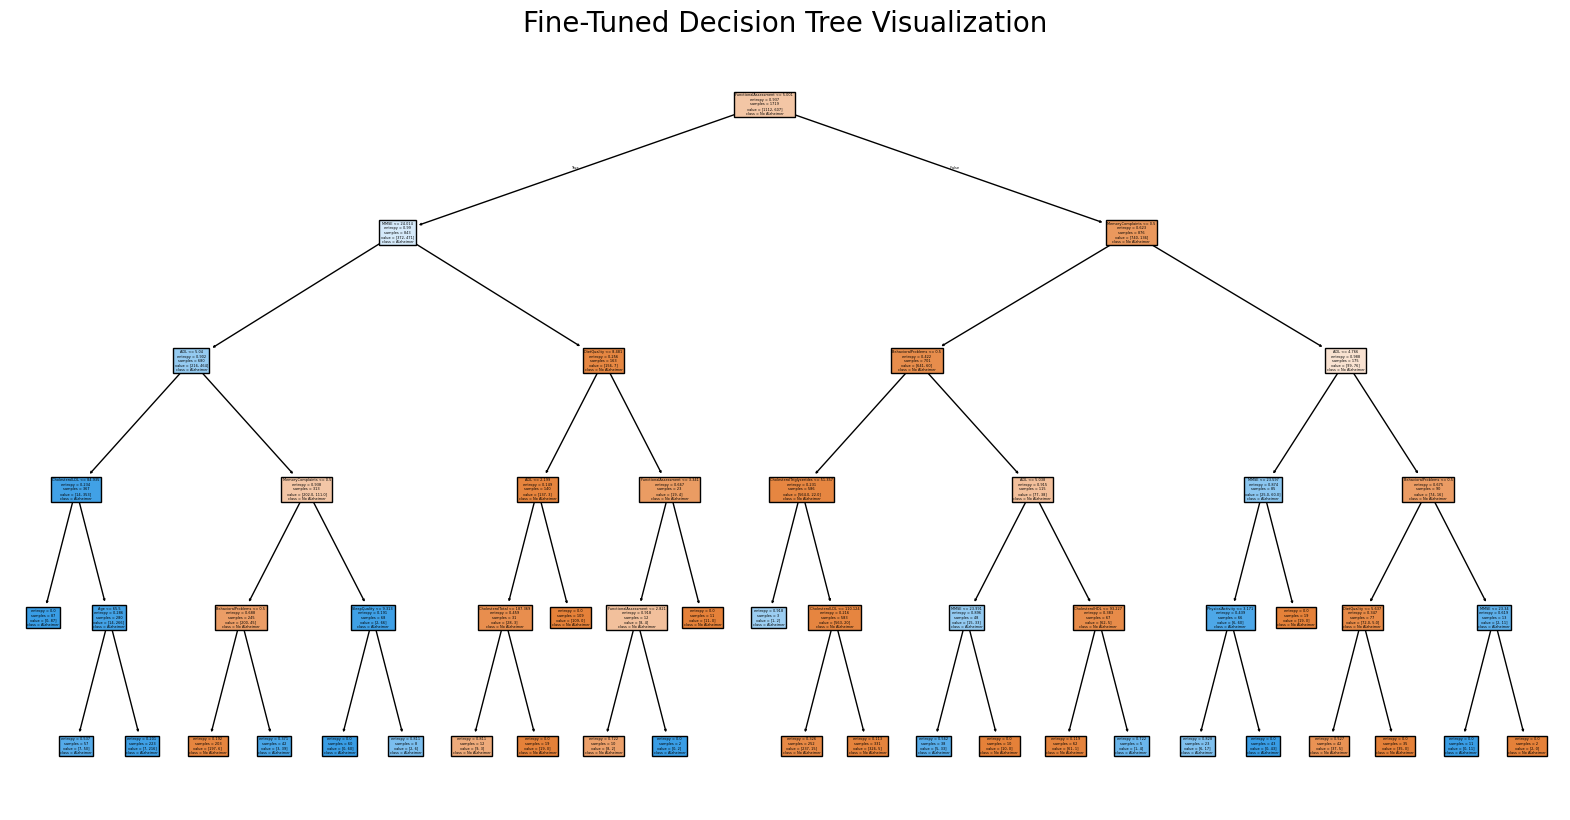

In [ ]:
# Visualizing the trained decision tree
plt.figure(figsize=(20,10))
tree.plot_tree(
    best_dt_model,
    feature_names=X.columns,
    class_names=['No Alzheimer', 'Alzheimer'],
    filled=True
)
plt.title("Fine-Tuned Decision Tree Visualization", fontsize=20)
plt.show()

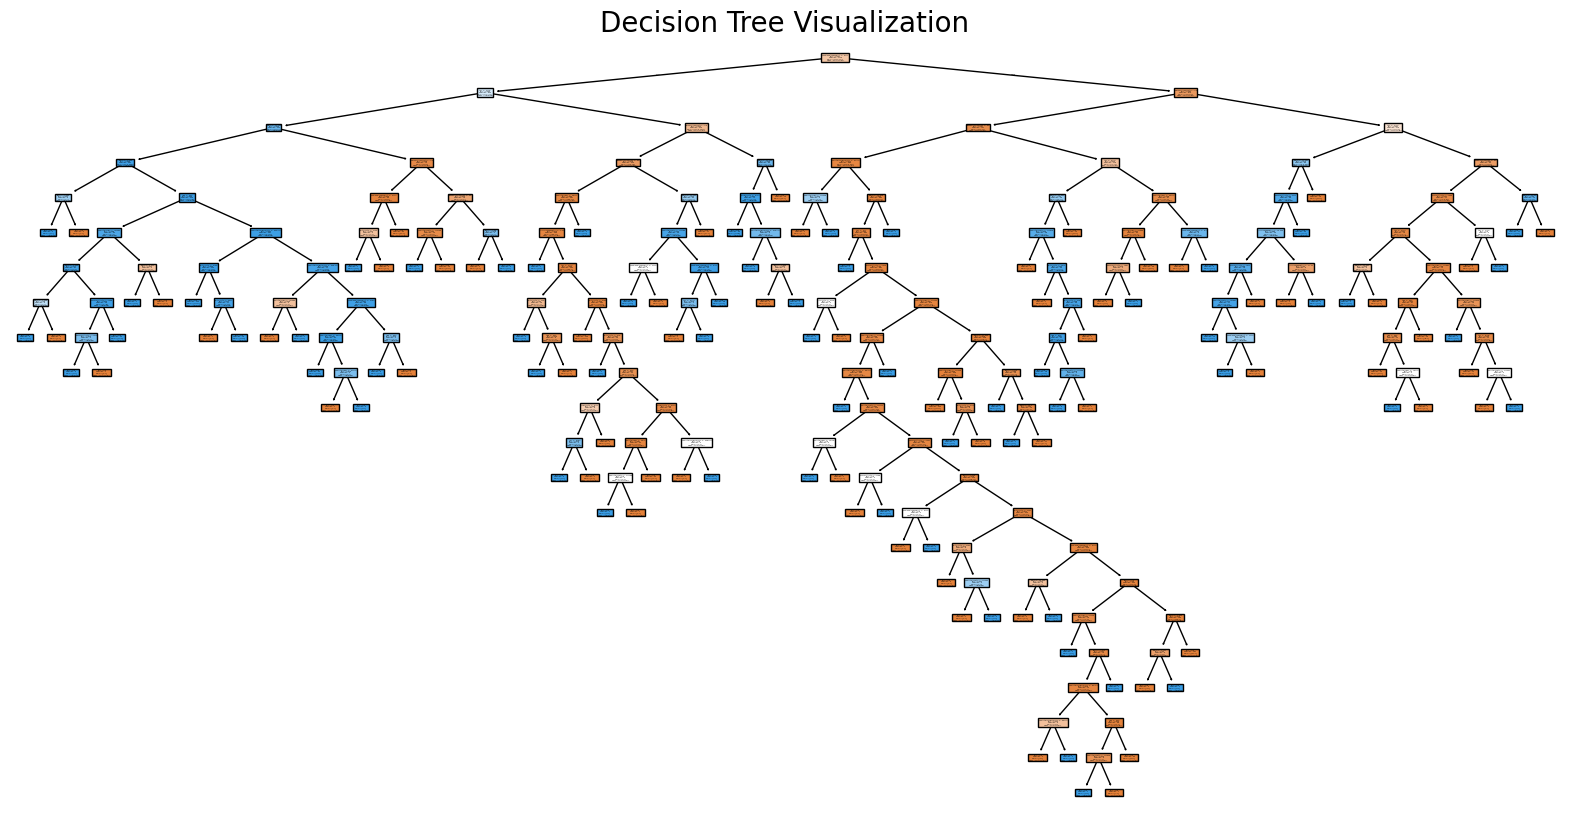

In [ ]:
# Visualizing the trained decision tree
plt.figure(figsize=(20,10))
tree.plot_tree(
    dt,
    feature_names=X.columns,
    class_names=['No Alzheimer', 'Alzheimer'],
    filled=True
)
plt.title("Decision Tree Visualization", fontsize=20)
plt.show()

# 3. KNN Model 🐾

---

# 🧠 Data Processing

In [ ]:
df = pd.read_csv(csv_path)

print("Column headers:", df.columns.tolist())

Column headers: ['PatientID', 'Age', 'Gender', 'Ethnicity', 'EducationLevel', 'BMI', 'Smoking', 'AlcoholConsumption', 'PhysicalActivity', 'DietQuality', 'SleepQuality', 'FamilyHistoryAlzheimers', 'CardiovascularDisease', 'Diabetes', 'Depression', 'HeadInjury', 'Hypertension', 'SystolicBP', 'DiastolicBP', 'CholesterolTotal', 'CholesterolLDL', 'CholesterolHDL', 'CholesterolTriglycerides', 'MMSE', 'FunctionalAssessment', 'MemoryComplaints', 'BehavioralProblems', 'ADL', 'Confusion', 'Disorientation', 'PersonalityChanges', 'DifficultyCompletingTasks', 'Forgetfulness', 'Diagnosis', 'DoctorInCharge']


In [ ]:
selected_features = ['MMSE', 'ADL', 'FunctionalAssessment', 'MemoryComplaints', 'BehavioralProblems', 'PhysicalActivity', 'DietQuality', 'CholesterolHDL', 'BMI', 'CholesterolLDL', 'CholesterolTotal', 'Diagnosis']
df = df[selected_features]

# Display missing values
print("Missing values before handling:")
print(df.isnull().sum())

Missing values before handling:
MMSE                    0
ADL                     0
FunctionalAssessment    0
MemoryComplaints        0
BehavioralProblems      0
PhysicalActivity        0
DietQuality             0
CholesterolHDL          0
BMI                     0
CholesterolLDL          0
CholesterolTotal        0
Diagnosis               0
dtype: int64


In [ ]:
# Define features (X) and diagnosis (y)
X_knn = df.drop(['Diagnosis'], axis=1)
y=df['Diagnosis']

# Spil the data

In [ ]:
# Train-test split (80/20)
X_train_knn, X_test_knn, y_train_knn, y_test_knn = train_test_split(X_knn, y, test_size=0.2, random_state=42)

# ⚖️ Feature Scaling
Feature scaling standardizes the features so that they contribute equally to the model's performance.

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_knn)
X_test_scaled = scaler.transform(X_test_knn)

# Build the KNN Model

In [ ]:
# define the parameters we are gonna iterate through

n_neighbors = list(range(1,20))

test_accuracy = {}
train_accuracy = {}

for n in n_neighbors:
    clf = KNeighborsClassifier(n_neighbors = n)
    clf.fit(X_train_scaled, y_train_knn)
    test_acc = clf.score(X_test_scaled, y_test_knn)
    train_acc = clf.score(X_train_scaled, y_train_knn)
    test_accuracy[n] = test_acc
    train_accuracy[n] = train_acc

In [ ]:
for k, v in test_accuracy.items():
    print("test accuracy for {} n_neighbors is {} %".format(k, round(v*100, 3)))

test accuracy for 1 n_neighbors is 79.535 %
test accuracy for 2 n_neighbors is 80.0 %
test accuracy for 3 n_neighbors is 83.488 %
test accuracy for 4 n_neighbors is 84.419 %
test accuracy for 5 n_neighbors is 85.349 %
test accuracy for 6 n_neighbors is 83.953 %
test accuracy for 7 n_neighbors is 83.953 %
test accuracy for 8 n_neighbors is 82.326 %
test accuracy for 9 n_neighbors is 83.256 %
test accuracy for 10 n_neighbors is 82.791 %
test accuracy for 11 n_neighbors is 83.256 %
test accuracy for 12 n_neighbors is 83.023 %
test accuracy for 13 n_neighbors is 84.419 %
test accuracy for 14 n_neighbors is 85.116 %
test accuracy for 15 n_neighbors is 85.814 %
test accuracy for 16 n_neighbors is 85.116 %
test accuracy for 17 n_neighbors is 85.814 %
test accuracy for 18 n_neighbors is 83.953 %
test accuracy for 19 n_neighbors is 85.116 %


In [ ]:
for k, v in train_accuracy.items():
    print("training accuracy for {} n_neighbors is {} %".format(k, round(v*100, 3)))

training accuracy for 1 n_neighbors is 100.0 %
training accuracy for 2 n_neighbors is 90.285 %
training accuracy for 3 n_neighbors is 91.623 %
training accuracy for 4 n_neighbors is 89.063 %
training accuracy for 5 n_neighbors is 88.889 %
training accuracy for 6 n_neighbors is 88.133 %
training accuracy for 7 n_neighbors is 88.307 %
training accuracy for 8 n_neighbors is 88.074 %
training accuracy for 9 n_neighbors is 88.773 %
training accuracy for 10 n_neighbors is 87.9 %
training accuracy for 11 n_neighbors is 88.191 %
training accuracy for 12 n_neighbors is 87.725 %
training accuracy for 13 n_neighbors is 87.667 %
training accuracy for 14 n_neighbors is 87.202 %
training accuracy for 15 n_neighbors is 87.725 %
training accuracy for 16 n_neighbors is 87.551 %
training accuracy for 17 n_neighbors is 87.202 %
training accuracy for 18 n_neighbors is 87.318 %
training accuracy for 19 n_neighbors is 87.086 %


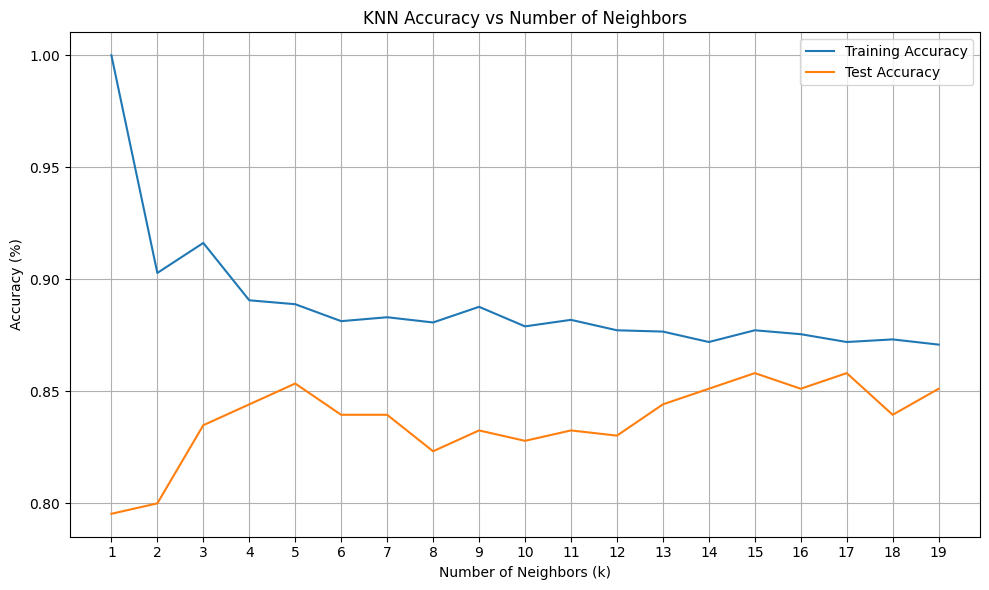

In [ ]:
# Create lists for plotting
test_acc_values = [test_accuracy[n] for n in n_neighbors]
train_acc_values = [train_accuracy[n] for n in n_neighbors]

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(n_neighbors, train_acc_values, label='Training Accuracy')
plt.plot(n_neighbors, test_acc_values, label='Test Accuracy')
plt.title('KNN Accuracy vs Number of Neighbors')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Accuracy (%)')
plt.xticks(n_neighbors)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

> In the plot, we observe that as the number of neighbors increases, the training accuracy gradually decreases while the test accuracy increases and then stabilizes. At **k = 17**, the test accuracy reaches one of its highest points, and more importantly, the training and test accuracy curves are very close to each other. *This indicates that choosing k = 17 achieves a good balance between bias and variance.* In contrast, for smaller values of k, there is a significant gap between the training and test accuracies, suggesting overfitting.






In [ ]:
knn = KNeighborsClassifier(n_neighbors=17)
knn.fit(X_train_scaled, y_train_knn)

KNeighborsClassifier(n_neighbors=17)

# Evaluate the Model

In [ ]:
#evaluate the model's accuracy
training_acc=knn.score(X_train_scaled, y_train_knn)
test_acc=knn.score(X_test_scaled, y_test_knn)

In [ ]:
training_acc, test_acc

(0.8720186154741129, 0.858139534883721)

In [ ]:
#Predict on test data

predictions_knn = knn.predict(X_test_scaled)
predictions_knn

array([0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1,
       0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0,
       0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0,
       1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0,
       1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0,
       0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1,
       0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1,
       0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0,
       1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1,
       1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0,
       1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0,

In [ ]:
knn.predict_proba(X_test_scaled) #probabilities for each class

array([[0.76470588, 0.23529412],
       [0.58823529, 0.41176471],
       [0.70588235, 0.29411765],
       [0.94117647, 0.05882353],
       [1.        , 0.        ],
       [0.94117647, 0.05882353],
       [0.17647059, 0.82352941],
       [0.94117647, 0.05882353],
       [0.76470588, 0.23529412],
       [0.23529412, 0.76470588],
       [0.58823529, 0.41176471],
       [0.17647059, 0.82352941],
       [0.52941176, 0.47058824],
       [0.88235294, 0.11764706],
       [0.82352941, 0.17647059],
       [0.94117647, 0.05882353],
       [0.47058824, 0.52941176],
       [0.05882353, 0.94117647],
       [0.94117647, 0.05882353],
       [0.52941176, 0.47058824],
       [0.41176471, 0.58823529],
       [0.05882353, 0.94117647],
       [0.64705882, 0.35294118],
       [1.        , 0.        ],
       [0.88235294, 0.11764706],
       [0.47058824, 0.52941176],
       [0.88235294, 0.11764706],
       [0.82352941, 0.17647059],
       [1.        , 0.        ],
       [1.        , 0.        ],
       [1.

# Fine-Tune the KNN Model

In [ ]:
# Define the hyperparameter distribution
param_dist_knn = {
    'n_neighbors': range(1, 20),  # Try K from 1 to 9
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan'],
    'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute']
}

# Random search with 5-fold cross-validation using F1 score
random_search_knn = RandomizedSearchCV(
    estimator=KNeighborsClassifier(),
    param_distributions=param_dist_knn,
    n_iter=20,              # Try 20 random combinations
    scoring='f1',           # F1 score (focuses on positive class)
    cv=5,
    n_jobs=-1,
    random_state=42
)

# Fit the model to the training data
random_search_knn.fit(X_train_scaled, y_train_knn)

# Evaluate the best model on the test set
best_knn_model = random_search_knn.best_estimator_
predictions_best_knn = best_knn_model.predict(X_test_scaled)

# Compare the parametres of Knn model and the Knn fine-tuned model.

In [ ]:
# check parametres

print("Parameters of KNN model:")
print(knn.get_params())
print("\n")

print("Parameters of fine-tuned KNN model:")
print(best_knn_model.get_params())

Parameters of KNN model:
{'algorithm': 'auto', 'leaf_size': 30, 'metric': 'minkowski', 'metric_params': None, 'n_jobs': None, 'n_neighbors': 17, 'p': 2, 'weights': 'uniform'}


Parameters of fine-tuned KNN model:
{'algorithm': 'kd_tree', 'leaf_size': 30, 'metric': 'euclidean', 'metric_params': None, 'n_jobs': None, 'n_neighbors': 15, 'p': 2, 'weights': 'uniform'}


# Compare the classification reposrt of each model:

In [ ]:
print("Original KNN Classification Report:")
report_or = classification_report(y_test_knn, predictions_knn, target_names=['No Alzheimer', 'Alzheimer'])
print(report_or)

print("\n")
print("Fine-tuned KNN Classification Report:")
report_ft = classification_report(y_test_knn, predictions_best_knn, target_names=['No Alzheimer', 'Alzheimer'])
print(report_ft)

Original KNN Classification Report:
              precision    recall  f1-score   support

No Alzheimer       0.88      0.91      0.89       277
   Alzheimer       0.82      0.76      0.79       153

    accuracy                           0.86       430
   macro avg       0.85      0.84      0.84       430
weighted avg       0.86      0.86      0.86       430



Fine-tuned KNN Classification Report:
              precision    recall  f1-score   support

No Alzheimer       0.88      0.91      0.89       277
   Alzheimer       0.82      0.76      0.79       153

    accuracy                           0.86       430
   macro avg       0.85      0.84      0.84       430
weighted avg       0.86      0.86      0.86       430



In [ ]:
print("Original KNN Classification Report:")
print("Accuracy:", accuracy_score(y_test_knn, predictions_knn))
print("Precision:",precision_score(y_test_knn, predictions_knn))
print("Recall:",recall_score(y_test_knn, predictions_knn))
print("F1 Score:",f1_score(y_test_knn, predictions_knn))

print("\n")
print("Fine-tuned KNN Classification Report:")
print("Accuracy:", accuracy_score(y_test_knn, predictions_best_knn))
print("Precision:",precision_score(y_test_knn, predictions_best_knn))
print("Recall:",recall_score(y_test_knn,predictions_best_knn))
print("F1 Score:",f1_score(y_test_knn, predictions_best_knn))

Original KNN Classification Report:
Accuracy: 0.858139534883721
Precision: 0.823943661971831
Recall: 0.7647058823529411
F1 Score: 0.7932203389830509


Fine-tuned KNN Classification Report:
Accuracy: 0.858139534883721
Precision: 0.823943661971831
Recall: 0.7647058823529411
F1 Score: 0.7932203389830509


# 📈 Confusion matrixes to compare results for decision tree and KNN

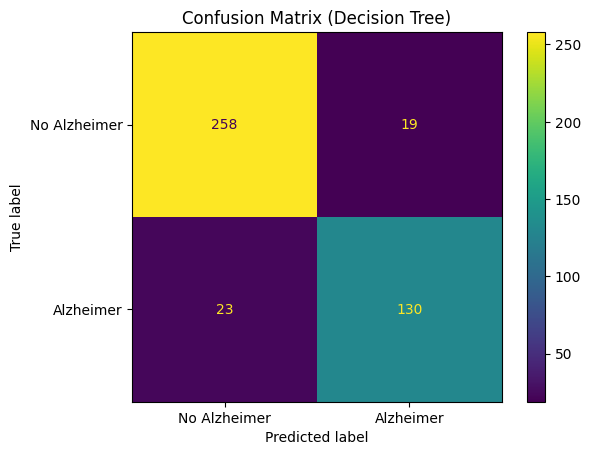

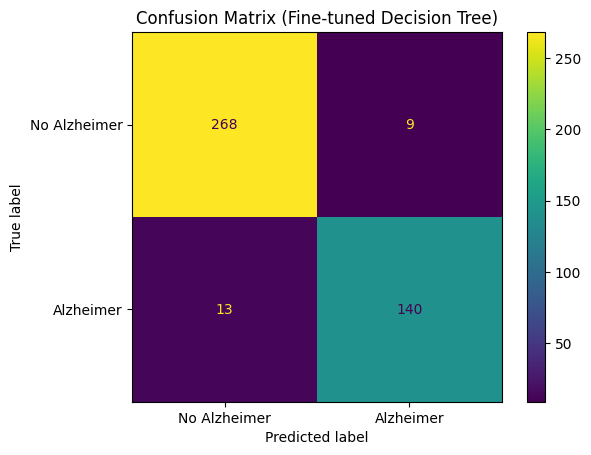

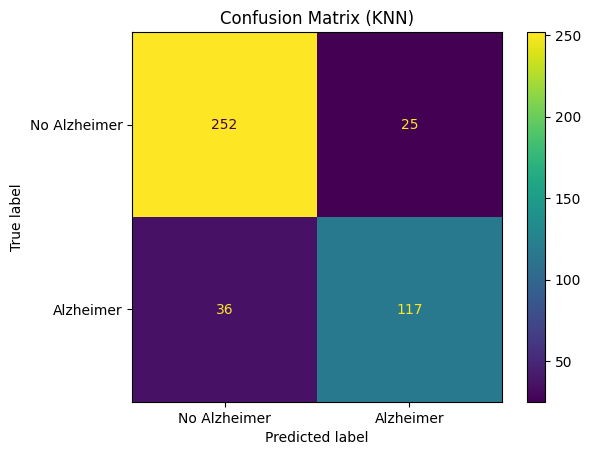

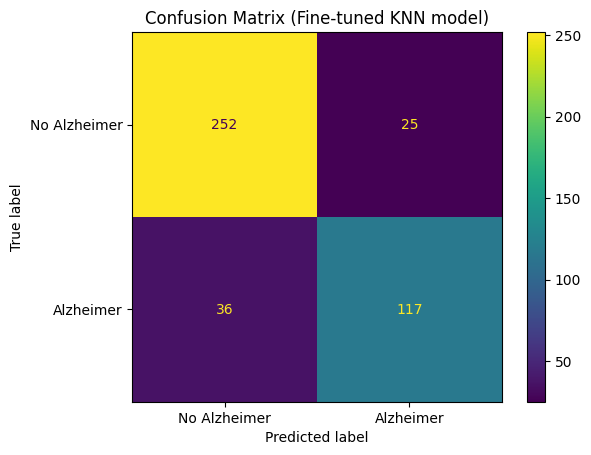

In [ ]:
#Confusion Matrix

cm = confusion_matrix(y_test, predictions, labels=[0,1])
cm_best = confusion_matrix(y_test, predictions_best_dt, labels=[0,1])
cm_knn = confusion_matrix(y_test_knn, predictions_knn, labels=[0,1])
cm_knn_best = confusion_matrix(y_test_knn, predictions_best_knn, labels=[0,1])

#Display the Confusion Matrix (Decision Tree)
dispCm = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Alzheimer', 'Alzheimer'])
dispCm.plot()
plt.title("Confusion Matrix (Decision Tree)")
plt.show()

#Display the Confusion Matrix (Decision Tree)
dispCm_best = ConfusionMatrixDisplay(confusion_matrix=cm_best, display_labels=['No Alzheimer', 'Alzheimer'])
dispCm_best.plot()
plt.title("Confusion Matrix (Fine-tuned Decision Tree)")
plt.show()

#Display the Confusion Matrix (KNN)
dispCm_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=['No Alzheimer', 'Alzheimer'])
dispCm_knn.plot()
plt.title("Confusion Matrix (KNN)")
plt.show()

#Display the Confusion Matrix (KNN best model)
dispCm_knn_best = ConfusionMatrixDisplay(confusion_matrix=cm_knn_best, display_labels=['No Alzheimer', 'Alzheimer'])
dispCm_knn_best.plot()
plt.title("Confusion Matrix (Fine-tuned KNN model)")
plt.show()


# 🔄 Model Evaluation with Multiple Train/Test Splits

We now test our models using different train-test splits to evaluate their stability and robustness.


In [ ]:
splits = [(0.6, 0.4), (0.7, 0.3), (0.67, 0.33), (0.8, 0.2), (0.82, 0.18)]
results = []

for train_size, test_size in splits:
    X_train, X_test, y_train, y_test = train_test_split(X_knn, y, train_size=train_size, test_size=test_size, random_state=42)

    # Scaled x_train and x_test for k-nn
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Train KNN
    knn = KNeighborsClassifier(weights= 'uniform', n_neighbors= 15, metric= 'euclidean')
    knn.fit(X_train_scaled, y_train)
    knn_preds = knn.predict(X_test_scaled)

    # Train Decision Tree
    dt = DecisionTreeClassifier(max_depth= 5, min_samples_leaf= 2, min_samples_split= 10, random_state=42)
    dt.fit(X_train, y_train)
    dt_preds = dt.predict(X_test)

    results.append({
        'Split': f'{int(train_size*100)}/{int(test_size*100)}',
        'KNN_Accuracy': accuracy_score(y_test, knn_preds),
        'KNN_Precision': precision_score(y_test, knn_preds),
        'KNN_Recall': recall_score(y_test, knn_preds),
        'KNN_F1': f1_score(y_test, knn_preds),
        'DT_Accuracy': accuracy_score(y_test, dt_preds),
        'DT_Precision': precision_score(y_test, dt_preds),
        'DT_Recall': recall_score(y_test, dt_preds),
        'DT_F1': f1_score(y_test, dt_preds),
    })

# Convert results to DataFrame for comparison
results_df = pd.DataFrame(results)
results_df

,Split,KNN_Accuracy,KNN_Precision,KNN_Recall,KNN_F1,DT_Accuracy,DT_Precision,DT_Recall,DT_F1
0,60/40,0.833721,0.813869,0.707937,0.757216,0.934884,0.938983,0.879365,0.908197
1,70/30,0.832558,0.820755,0.713115,0.763158,0.925581,0.937500,0.860656,0.897436
2,67/33,0.833803,0.812766,0.720755,0.764000,0.928169,0.938525,0.864151,0.899804
3,80/20,0.858140,0.823944,0.764706,0.793220,0.927907,0.923611,0.869281,0.895623
4,82/18,0.857881,0.825758,0.773050,0.798535,0.930233,0.925373,0.879433,0.901818


# Conclusion 📝
Using K-Nearest Neighbors (KNN) and Decision Trees, we built models to predict disease diagnosis from patient data. Decision Trees offered interpretability, while a well-tuned KNN performed strongly, especially with proper feature scaling. Experimenting with different train-test splits showed that more data generally improved performance, though caution was needed to avoid overfitting. Evaluating models with accuracy, precision, recall, and F1-score gave a more complete view of effectiveness. While the models provide a solid baseline, further tuning and testing on real-world data are essential for clinical use.

# Insights:
- Certain features had a stronger correlation with diagnosis outcomes.
- Visualization helped validate assumptions and informed the feature engineering process.
- Machine learning can be a powerful tool to assist early diagnosis with careful preparation and validation.

This project provides a practical example of applying machine learning to a real-world healthcare dataset, reinforcing key concepts in supervised learning, model evaluation, and responsible data use.

